# Evaluation of Probabilistic and Non-Probabilistic Machine Learning Frameworks for Clinical Stroke Prediction

## Data Preprocessing

In [1]:
# Importing the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# load the dataset
df = pd.read_csv("health_stroke_dataset.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
# check the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# check for missing values
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# fill the column with missing values with the mean value of the column
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df["bmi"].isnull().value_counts()

bmi
False    5110
Name: count, dtype: int64

In [7]:
df["bmi"].values

array([36.6       , 28.89323691, 32.5       , ..., 30.6       ,
       25.6       , 26.2       ], shape=(5110,))

In [8]:
# Checking the cardinality
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [9]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   419
smoking_status          4
stroke                  2
dtype: int64

In [10]:
# Checking the unique values in gender column
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [11]:
df[df["gender"] =="Other"]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


Given that the dataset has only one gender labelled `other`, we have to drop the entire row in order to train our model well

In [12]:
# dropping the "Other" label rows
df = df[df["gender"] != "Other"].reset_index(drop = True)

In [13]:
# Checking the unique values in "work_type"
print(df["work_type"].unique())
print(df["Residence_type"].unique())
print(df["ever_married"].unique())
print(df["smoking_status"].unique())


['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['Yes' 'No']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


### **Encoding Categorical variables**  
the heart stroke dataset contains categorical data which is not very good for our model to train well.  
`gender`,`ever_married`, `work_type`, `Residence_type`, `smoking_status` are all categorical variables we need to encode

In [14]:
df[["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]].nunique()

gender            2
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

from the ".nunique()" method, `gender`, `ever_married`, and `Residence_type` can be encoded using one hot encoding

In [15]:
# Importing the Library for encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [16]:
# Encoding the variable "gender", "ever_married", "Residence_type"
encoder = LabelEncoder()
categorical_column = ["gender",
                      "ever_married", 
                      "Residence_type",
                      "smoking_status",
                     "work_type"] 

for column in categorical_column:
    df[column] = encoder.fit_transform(df[column])

In [17]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [18]:
# confirming the "gender" has been encoded
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   int64  
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   int64  
 6   work_type          5109 non-null   int64  
 7   Residence_type     5109 non-null   int64  
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                5109 non-null   float64
 10  smoking_status     5109 non-null   int64  
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 479.1 KB


Applying Ordinal Encoding on the `work_type`, `smoking_status`

### Scaling numerical features where appropriate.   
There are important variables that needs scaling like the `age` , `avg_glucose_level`, and `bmi` in order to train our model perfectly

In [19]:
# Import the Library for scaling
from sklearn.preprocessing import StandardScaler

In [20]:
# defining the scaler 
scaler = StandardScaler()
df[["age", 
    "avg_glucose_level", 
    "bmi"]] = scaler.fit_transform(df[["age",
                                       "avg_glucose_level", 
                                        "bmi"]])

In [21]:
df[["age", "avg_glucose_level", "bmi"]].head()

,age,avg_glucose_level,bmi
0,1.051242,2.706450,1.001041
1,0.785889,2.121652,-0.000165
2,1.626174,-0.004867,0.468399
3,0.255182,1.437473,0.715233
4,1.581949,1.501297,-0.635858


### Splitting the dataset into training and testing sets

variable like "id" is not going to be relevant to our model training. 

In [22]:
# importing the Library for dataset splitting
from sklearn.model_selection import train_test_split

In [23]:
# Defining the Predictor and Target variables
X = df.drop(columns = ["id", "stroke"])
y = df["stroke"]

In [24]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle = True,
                                                    random_state = 42,
                                                    stratify = y,
                                                    test_size = 0.2)

In [25]:
# Confirm the shape of training and testing dataset
print(f"Training Features: {X_train.shape}")
print(f"Training Target: {y_train.shape}")
print(f"Testing Feature: {X_test.shape}")
print(f"Testing Target: {y_test.shape}")

Training Features: (4087, 10)
Training Target: (4087,)
Testing Feature: (1022, 10)
Testing Target: (1022,)


## Model Development

### `a.` Probabilistic Classification  
> Logistic Regression 

In [26]:
# Importing the Library for the Logistics Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (recall_score,
f1_score,
accuracy_score,
precision_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay)

In [78]:
# Defining the Logistic Regression
logistic_model = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

In [28]:
# fitting the model into the train set
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


> **Report the model parameters.**

In [29]:
print(f"Coefficients {logistic_model.coef_}")
print(f"Intercept {logistic_model.intercept_}")

Coefficients [[ 0.08173946  1.57234367  0.4848217   0.18878085 -0.22263565 -0.06110995
   0.11403616  0.1900073   0.02114696  0.00363522]]
Intercept [-3.86908503]


> **Perform hyperparameter tuning where appropriate and justify the selected parameter 
values.**

In [86]:
# Hyperparameter tuning
grid_param = {
    "C" : [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid_search = GridSearchCV(
    estimator = logistic_model,
    param_grid = grid_param,
    cv = 5,
    scoring = "accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [88]:
print(f"Best Parameter: {grid_search.best_params_}")

Best Parameter: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


In [32]:
# Training the optimized model
best_logistic_model = grid_search.best_estimator_
best_logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
# Making Predictions
y_pred_logistic = best_logistic_model.predict(X_test)
y_prob_logistic = best_logistic_model.predict_proba(X_test)[:, 1]

> Naïve Bayes 

In [34]:
# Importing Libraries for the Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

In [35]:
# creating the Gaussian classifier
naive_bayes_model = GaussianNB()

In [36]:
# fitting the model
naive_bayes_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [93]:
y_pred_nb = naive_bayes_model.predict(X_test)

### `b.` Non-Probabilistic Classification Models  
> Support Vector Machine (SVM) 

In [42]:
# Import the Libraries for the Operation
from sklearn.svm import SVC

In [43]:
# creating the support vector machine classifier
svm_model = SVC(
    kernel = "linear",
    C = 1e6
)


In [44]:
svm_model.fit(X_train, y_train)

,C,1000000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
# Predict the class labels

y_pred_svm = svm_model.predict(X_test)

> K-Nearest Neighbours (KNN) 

In [49]:
# Importing Libraries for KNN
from sklearn.neighbors import KNeighborsClassifier

In [101]:
# Create the KNN classifier
knn_model = KNeighborsClassifier()

parameter_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_knn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [115]:
# Fitting the knn_model
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [102]:
# Display the best parameters

print("Best Parameters:")
print(grid_search_knn.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}


In [103]:
# Training the optimized model
best_knn_model = grid_search_knn.best_estimator_

best_knn_model.fit(X_train, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [104]:
y_pred_knn = knn_grid.predict(X_test)

## `5.` Model Evaluation 

> Logistic Regression

In [98]:
from sklearn.metrics import (accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
roc_curve,
roc_auc_score)


In [87]:
print("Logistic Regression")
print("Accuracy", accuracy_score(y_test, y_pred_logistic) )
print("Precision", precision_score(y_test, y_pred_logistic))
print("F1_score", f1_score(y_test, y_pred_logistic))
print(f"Recall {recall_score(y_test, y_pred_logistic)}")
print("Classification Report")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
Accuracy 0.9510763209393346
Precision 0.0
F1_score 0.0
Recall 0.0
Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-pa

In [95]:
print("Naive Bayes")
print("Accuracy", accuracy_score(y_test, y_pred_nb) )
print("Precision", precision_score(y_test, y_pred_nb))
print("F1_score", f1_score(y_test, y_pred_nb))
print(f"Recall {recall_score(y_test, y_pred_nb)}")
print("Classification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy 0.8649706457925636
Precision 0.16153846153846155
F1_score 0.23333333333333334
Recall 0.42
Classification Report
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       972
           1       0.16      0.42      0.23        50

    accuracy                           0.86      1022
   macro avg       0.56      0.65      0.58      1022
weighted avg       0.93      0.86      0.89      1022



In [77]:
print("Support Vector Machine (SVM)")
print("Accuracy", accuracy_score(y_test, y_pred_svm) )
print("Precision", precision_score(y_test, y_pred_svm))
print("F1_score", f1_score(y_test, y_pred_svm))
print(f"Recall {recall_score(y_test, y_pred_svm)}")
print("Classification Report")
print(classification_report(y_test, y_pred_svm))


Support Vector Machine (SVM)
Accuracy 0.9510763209393346
Precision 0.0
F1_score 0.0
Recall 0.0
Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-pa

In [89]:
log=GridSearchCV(LogisticRegression(max_iter=1000),{'C':[0.01,0.1,1,10],'solver':['liblinear']},cv=5).fit(X_train,y_train).best_estimator_


In [96]:
print("K Nearest Neighbor")
print("Accuracy", accuracy_score(y_test, y_pred_knn) )
print("Precision", precision_score(y_test, y_pred_knn))
print("F1_score", f1_score(y_test, y_pred_knn))
print(f"Recall {recall_score(y_test, y_pred_knn)}")
print("Classification Report")
print(classification_report(y_test, y_pred_knn))

K Nearest Neighbor
Accuracy 0.9510763209393346
Precision 0.0
F1_score 0.0
Recall 0.0
Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-pa

> Plot the Receiver Operating Characteristic (ROC) curves  for the probabilistic models (Logistic Regression and Naïve Bayes): 

In [120]:
models = {
    "Logistic Regression": best_logistic_model,
    "Gaussian Naïve Bayes": naive_bayes_model,
    "Support Vector Machine": svm_model,
    "K-Nearest Neighbours": knn_model
}

In [121]:
results = []

for model_name, model in models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [125]:
# Comparing the Four models
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print(results_df)

                    Model  Accuracy  Precision  Recall  F1-Score
0     Logistic Regression  0.951076   0.000000    0.00  0.000000
1    Gaussian Naïve Bayes  0.864971   0.161538    0.42  0.233333
2  Support Vector Machine  0.951076   0.000000    0.00  0.000000
3    K-Nearest Neighbours  0.948141   0.000000    0.00  0.000000


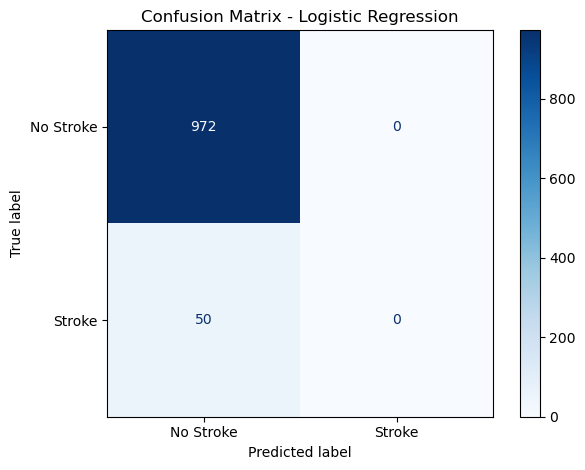

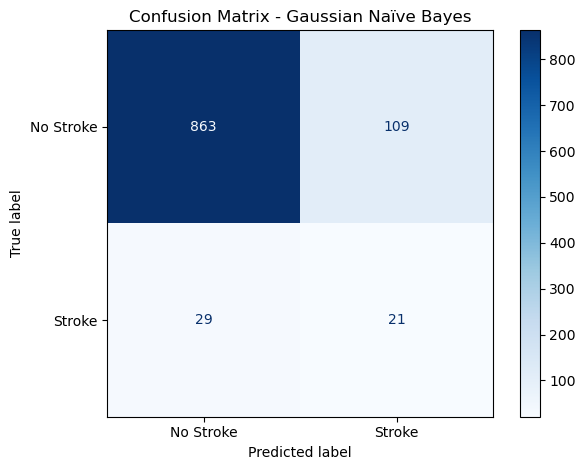

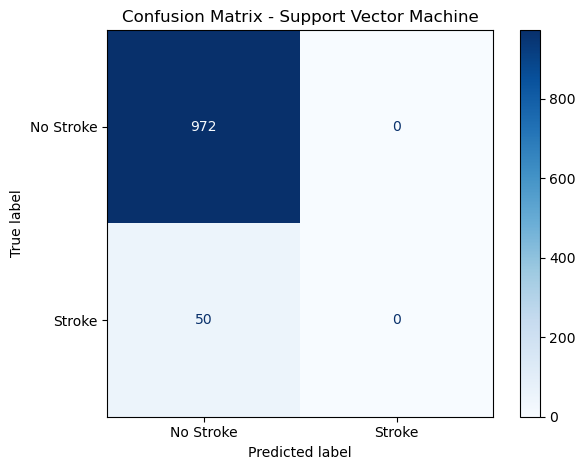

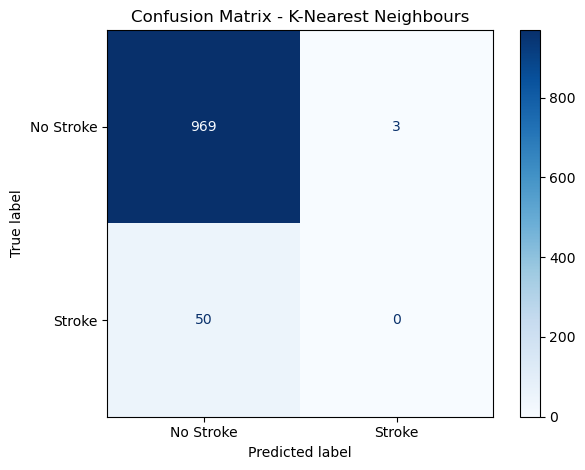

In [123]:
# Confusion Matrix for all models
for model_name, model in models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Stroke", "Stroke"]
    )

    disp.plot(cmap=plt.cm.Blues)

    plt.title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()

    plt.show()

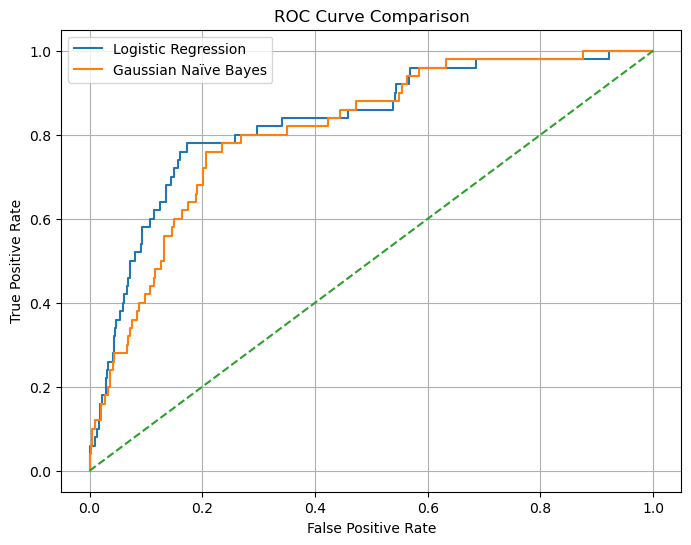

In [124]:
# ROC CURVES

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_logistic
)

# Gaussian Naïve Bayes
fpr_nb, tpr_nb, _ = roc_curve(
    y_test,
    y_prob_nb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    label="Gaussian Naïve Bayes"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()